### 一般流程
---
1. 采样(Loading)
2. 查阅说明书(Consulting the Docs)
3. 样本纯化/清洗(Cleaning)
4. 样本融合(Merging)
5. 分析/建模(Analysis)

### 数据初探四部曲
---
- 数据长什么样：打印前五行 _df.head()_
- 数据有多大（行数 * 列数） _df.shape_
- 列名有哪些 _df.columns_ & df.columns.to_list()_
- 简单的统计摘要 _df\[col1\].describe()_

In [1]:
import pandas as pd

加载数据

In [2]:
demo_df = pd.read_sas('data/DEMO_L.xpt')
bmx_df = pd.read_sas('data/BMX_L.xpt')
ghb_df = pd.read_sas('data/GHB_L.xpt')
# .xpt是二进制格式，需要用pandas打开

**read_sas()**
- SAS数据集文件（.sas7bdat格式）
- SAS传输文件（.xpt格式）

In [3]:
# 打印行数
print(f'''
人口数据（demo）大小： {demo_df.shape},
体测数据（BMX）大小： {bmx_df.shape},
糖化血红蛋白（GHB）大小： {ghb_df.shape}
''')


人口数据（demo）大小： (11933, 27),
体测数据（BMX）大小： (8860, 22),
糖化血红蛋白（GHB）大小： (7199, 3)



In [4]:
print(f'''
人口：{demo_df.columns.to_list()},
体测：{bmx_df.columns.to_list()},
化验：{ghb_df.columns.to_list()}
''')


人口：['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR'],
体测：['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP'],
化验：['SEQN', 'WTPH2YR', 'LBXGH']



In [5]:
# 筛选我们需要的数据
demo_subset = demo_df.loc[:,['SEQN', 'RIAGENDR', 'RIDAGEYR',]]
bmx_subset = bmx_df[['SEQN','BMXWT','BMXHT','BMXBMI','BMXWAIST',]]
ghb_subset = ghb_df[['SEQN','LBXGH',]]

合并数据

In [6]:
# 融合数据
# 分步合并
temp_df = pd.merge(demo_subset,bmx_subset,on='SEQN',how='inner')
final_df = pd.merge(temp_df,ghb_subset,on='SEQN',how='inner')
print(final_df.shape)
final_df

(7199, 8)


,SEQN,RIAGENDR,RIDAGEYR,BMXWT,BMXHT,BMXBMI,BMXWAIST,LBXGH
0,130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6
1,130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6
2,130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2
3,130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1
4,130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9
...,...,...,...,...,...,...,...,...
7194,142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0
7195,142307.0,2.0,49.0,NaN,143.8,NaN,NaN,6.2
7196,142308.0,1.0,50.0,79.3,173.3,26.4,98.4,NaN
7197,142309.0,1.0,40.0,81.9,179.1,25.5,96.0,5.2


In [7]:
# reduce配合merge合并
from functools import reduce
final_df1 = reduce(lambda left,right: pd.merge(left,right,on='SEQN',how='inner'),[demo_subset,bmx_subset,ghb_subset])
final_df1.set_index('SEQN',inplace=True)
final_df1

,RIAGENDR,RIDAGEYR,BMXWT,BMXHT,BMXBMI,BMXWAIST,LBXGH
SEQN,,,,,,,
130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6
130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6
130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2
130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1
130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9
...,...,...,...,...,...,...,...
142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0
142307.0,2.0,49.0,NaN,143.8,NaN,NaN,6.2
142308.0,1.0,50.0,79.3,173.3,26.4,98.4,NaN


In [8]:
# concat合并
demo_subset_indexed = demo_subset.set_index('SEQN')
bmx_subset_indexed = bmx_subset.set_index('SEQN')
ghb_subset_indexed = ghb_subset.set_index('SEQN')

concat_result = pd.concat([demo_subset_indexed,bmx_subset_indexed,ghb_subset_indexed],axis=1,join='inner')
concat_result

,RIAGENDR,RIDAGEYR,BMXWT,BMXHT,BMXBMI,BMXWAIST,LBXGH
SEQN,,,,,,,
130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6
130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6
130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2
130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1
130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9
...,...,...,...,...,...,...,...
142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0
142307.0,2.0,49.0,NaN,143.8,NaN,NaN,6.2
142308.0,1.0,50.0,79.3,173.3,26.4,98.4,NaN


重命名列名&填补空缺值

In [9]:
rename_dict = {
    'RIAGENDR' : 'Gender',
    'RIDAGEYR': 'Age',
    'BMXWT':    'Weight',
    'BMXHT':    'Height',
    'BMXBMI':   'BMI',
    'BMXWAIST': 'Waist',
    'LBXGH':    'HbA1c',
}

final_df.rename(columns=rename_dict,inplace=True)
# inplace=True代表直接修改数据，不需要赋值给新变量
# print(final_df.isnull().sum())
final_df

,SEQN,Gender,Age,Weight,Height,BMI,Waist,HbA1c
0,130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6
1,130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6
2,130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2
3,130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1
4,130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9
...,...,...,...,...,...,...,...,...
7194,142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0
7195,142307.0,2.0,49.0,NaN,143.8,NaN,NaN,6.2
7196,142308.0,1.0,50.0,79.3,173.3,26.4,98.4,NaN
7197,142309.0,1.0,40.0,81.9,179.1,25.5,96.0,5.2


- HbA1c(糖化血红蛋白)：缺了484个值，这是我们的评估是否有糖尿病的标准，必须去除缺失样本
- Waist/BMI/Weight (特征缺失)：虽然可以填平均值（比如把缺失的人都填成平均腰围），但在医疗数据里这有风险。腰围是预测代谢病的关键，填一个假的平均值可能会误导模型

In [10]:
final_df.dropna(inplace=True)
# dropna() 默认删除任何包含 NaN 的行
# inplace=True 表示直接在原数据上动刀
final_df

,SEQN,Gender,Age,Weight,Height,BMI,Waist,HbA1c
0,130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6
1,130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6
2,130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2
3,130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1
4,130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9
...,...,...,...,...,...,...,...,...
7191,142302.0,1.0,70.0,55.8,161.5,21.4,79.7,5.2
7192,142303.0,2.0,69.0,70.8,159.2,27.9,111.0,8.1
7194,142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0
7197,142309.0,1.0,40.0,81.9,179.1,25.5,96.0,5.2


- 正常： HbA1c < 5.7%
- 前驱糖尿病 (Pre-diabetes)： 5.7% <= HbA1c < 6.5%
- 糖尿病 (Diabetes)： HbA1c >= 6.5%

In [11]:
# 创建新列
# final_df['Has_Diabetes'] = (final_df['HbA1c'] >= 6.5).astype(int)
# astype(int) 会把 True 变成 1， False 变成 0
#
# num_patients = final_df['Has_Diabetes'].sum()
# total_people = len(final_df)
# print(f"糖尿病患者人数: {num_patients}")
# print(f"患病率: {num_patients / total_people * 100:.2f}%")

In [12]:
import numpy as np
conditions = [
    final_df['HbA1c'] < 5.7,
    (final_df['HbA1c'] >= 5.7 ) & (final_df['HbA1c'] < 6.5),
    final_df['HbA1c'] >= 6.5,
]

choices = ['normal','pre_diabetes','diabetes']

final_df['Has_Diabetes'] = np.select(
    conditions,
    choices,
    default='unknown'  # 或者 default=''，取决于你希望如果不满足任何条件时填什么
)
final_df

,SEQN,Gender,Age,Weight,Height,BMI,Waist,HbA1c,Has_Diabetes
0,130378.0,1.0,43.0,86.9,179.5,27.0,98.3,5.6,normal
1,130379.0,1.0,66.0,101.8,174.2,33.5,114.7,5.6,normal
2,130380.0,2.0,44.0,69.4,152.9,29.7,93.5,6.2,pre_diabetes
3,130386.0,1.0,34.0,90.6,173.3,30.2,106.1,5.1,normal
4,130387.0,2.0,68.0,103.5,155.9,42.6,122.0,5.9,pre_diabetes
...,...,...,...,...,...,...,...,...,...
7191,142302.0,1.0,70.0,55.8,161.5,21.4,79.7,5.2,normal
7192,142303.0,2.0,69.0,70.8,159.2,27.9,111.0,8.1,diabetes
7194,142305.0,2.0,76.0,60.4,151.4,26.4,89.0,6.0,pre_diabetes
7197,142309.0,1.0,40.0,81.9,179.1,25.5,96.0,5.2,normal


In [13]:
# # 糖尿病状态统计
# print('糖尿病状态分布：')
# print('-'*10)
# print('总人数：')
# print(final_df['Has_Diabetes'].count())
# print('-'*10)
# print('状态计数：')
# print(final_df['Has_Diabetes'].value_counts())
# print('-'*10)
# print('百分比：')
# print(final_df['Has_Diabetes'].value_counts(normalize=True).round(3)*100)
# print('-'*10)
# print('各糖尿病状态的 HbA1c 统计：')
# print(final_df.groupby('Has_Diabetes')['HbA1c'].agg(['count','mean','std','min','max']).round(2))

In [14]:
# 优化
# 1. 设定有序类别 (让输出按病情严重程度排序，而不是按人数排序)
order = ['normal', 'pre_diabetes', 'diabetes']
final_df['Has_Diabetes'] = pd.Categorical(final_df['Has_Diabetes'], categories=order, ordered=True)

# 2. 制作分布统计表 (合并计数和百分比)
dist_df = pd.DataFrame({
    'Count': final_df['Has_Diabetes'].value_counts(sort=False),
    'Percentage (%)': (final_df['Has_Diabetes'].value_counts(normalize=True, sort=False) * 100).round(1)
})

# 3. 制作详细统计表 (HbA1c)
stats_df = final_df.groupby('Has_Diabetes', observed=True)['HbA1c'].agg(
    Count='count',
    Mean='mean',
    Std='std',
    Min='min',
    Max='max'
).round(2)

# 4. 展示 (在Jupyter里直接显示变量，不用print)
from IPython.display import display
print(f"总样本数: {len(final_df)}")
print("-"*20)
print("分布情况:")
display(dist_df)
print("\n HbA1c 详细统计:")
display(stats_df)

总样本数: 6399
--------------------
分布情况:


,Count,Percentage (%)
Has_Diabetes,,
normal,4165,65.1
pre_diabetes,1569,24.5
diabetes,665,10.4



 HbA1c 详细统计:


,Count,Mean,Std,Min,Max
Has_Diabetes,,,,,
normal,4165,5.25,0.28,3.2,5.6
pre_diabetes,1569,5.92,0.21,5.7,6.4
diabetes,665,8.01,1.75,6.5,17.1


可视化分析糖尿病是否与BMI&Age有关

这是特征工程的核心依据

/tmp/ipykernel_10121/685523692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Diabetes', y='BMI', data=final_df, order=order_list, palette="Set2")


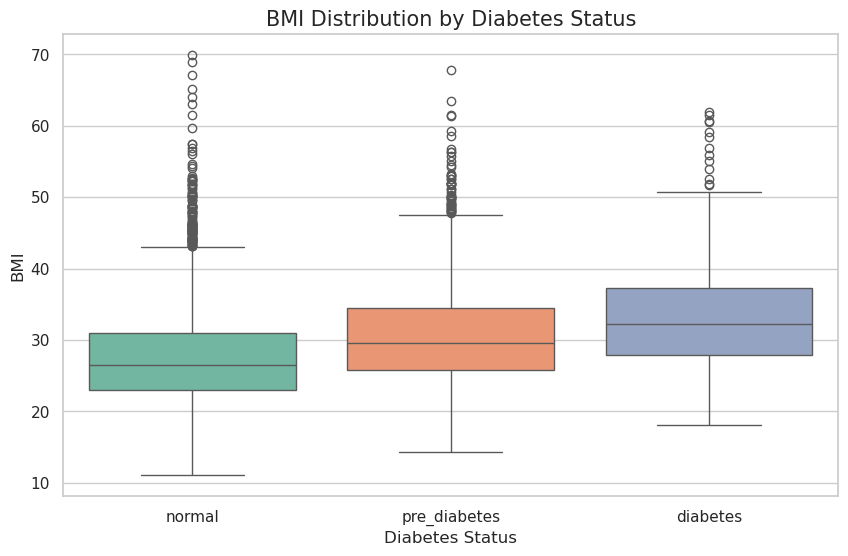

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置画图风格，让图好看点
sns.set_theme(style="whitegrid")

# 创建画布
plt.figure(figsize=(10, 6))

# 定义我们想要的顺序 (从正常到生病)
order_list = ['normal', 'pre_diabetes', 'diabetes']

# 画箱线图
# X轴：你的分类 (Has_Diabetes)
# Y轴：BMI (或者你可以换成 'Waist' 看看腰围)
sns.boxplot(x='Has_Diabetes', y='BMI', data=final_df, order=order_list, palette="Set2")

plt.title('BMI Distribution by Diabetes Status', fontsize=15)
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.show()

/tmp/ipykernel_10121/3070765348.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Diabetes', y='Age', data=final_df, order=order_list, palette="Set2")


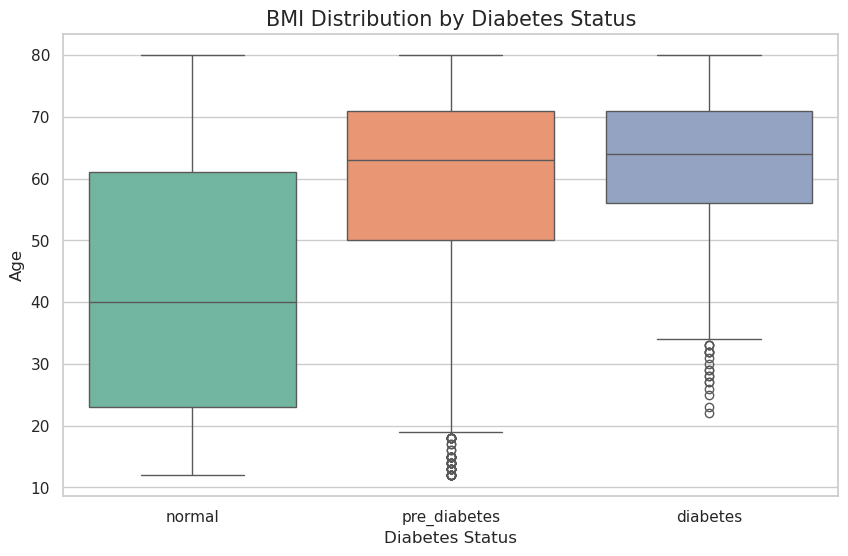

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置画图风格，让图好看点
sns.set_theme(style="whitegrid")

# 创建画布
plt.figure(figsize=(10, 6))

# 定义我们想要的顺序 (从正常到生病)
order_list = ['normal', 'pre_diabetes', 'diabetes']

# 画箱线图
# X轴：你的分类 (Has_Diabetes)
# Y轴：BMI (或者你可以换成 'Waist' 看看腰围)
sns.boxplot(x='Has_Diabetes', y='Age', data=final_df, order=order_list, palette="Set2")

plt.title('BMI Distribution by Diabetes Status', fontsize=15)
plt.xlabel('Diabetes Status')
plt.ylabel('Age')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 定义特征 (X) 和 标签 (y)
# 我们用这些非侵入式的指标来预测
feature_cols = ['Age', 'Gender', 'BMI', 'Waist', 'Height', 'Weight']
X = final_df[feature_cols]

# 2. 处理标签 (y)
# 机器只能读数字。我们将 'diabetes' 设为 1，其他(normal/pre) 都设为 0
# 目标：找出真正的糖尿病患者
y = final_df['Has_Diabetes'].apply(lambda x: 1 if x == 'diabetes' else 0)

# 3. 划分训练集和测试集
# 80% 的数据用来训练(复习)，20% 用来考试(测试)
# random_state=42 是为了保证咱俩结果一样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

训练集大小: (5119, 6)
测试集大小: (1280, 6)


In [18]:
# 1. 建立模型 (召唤随机森林)
# n_estimators=100 表示我们需要 100 棵决策树参与投票
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. 训练 (Fit)
print("模型正在学习中...")
rf_model.fit(X_train, y_train)

# 3. 预测 (Predict)
# 让模型对那 20% 没见过的病人进行诊断
y_pred = rf_model.predict(X_test)

# 4. 看看考了多少分
print("--- 诊断报告 ---")
print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n详细报告:")
print(classification_report(y_test, y_pred))

模型正在学习中...
--- 诊断报告 ---
准确率 (Accuracy): 0.8766

详细报告:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1136
           1       0.29      0.07      0.11       144

    accuracy                           0.88      1280
   macro avg       0.59      0.52      0.52      1280
weighted avg       0.83      0.88      0.84      1280



🚨 紧急诊断：模型“偷懒”了
- 表面看： 准确率 (Accuracy) 88%。看起来是个好学生，对吧？
- 实际看： 请盯着 Class 1 (有病) 的 Recall (召回率) —— 只有 0.07 (7%)。
这意味着什么？ 测试集里有 144 个真正的糖尿病患者，你的模型只把其中的 10 个人 (144 * 0.07) 找了出来。它漏掉了 93% 的病人！ 在医院里，这种模型是医疗事故级别的。它基本上是在对所有人说：“你没病，回家吧。” 因为大部分人确实没病，所以它的整体准确率还能混到 88%。

⚡️ 为什么会这样？(Imbalanced Data)
这是医疗数据最常见的问题：类别不平衡。 你的数据里，健康人占了 ~90%，病人才占 ~10%。 模型很“鸡贼”，它发现只要闭着眼全猜“健康”，准确率就能稳拿 90%。它根本没动力去学那难辨认的 10%。

🛠️ 修正方案：给模型“施压”
我们需要告诉随机森林：“漏掉一个病人的惩罚，是误判一个健康人的 10 倍！” 这样它就不敢偷懒了。

In [19]:
# --- 修正版模型训练 ---

# 1. 带权重的随机森林
# class_weight='balanced': 自动根据数据比例调整权重
# 少见的样本(病人)，权重会自动变大，迫使模型重视
rf_balanced = RandomForestClassifier(n_estimators=100,
                                     random_state=42,
                                     class_weight='balanced') # <--- 关键修改在这里！

# 2. 重新训练
print("正在进行加权训练...")
rf_balanced.fit(X_train, y_train)

# 3. 重新预测
y_pred_balanced = rf_balanced.predict(X_test)

# 4. 对比结果
print("--- 修正后的诊断报告 ---")
print(classification_report(y_test, y_pred_balanced))

# 额外查看：混淆矩阵 (Confusion Matrix)
# 这能让你直观看到到底漏了多少人
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_balanced)
print("\n混淆矩阵:")
print(f"真阴性 (没病判对): {cm[0][0]}\t 假阳性 (没病判病): {cm[0][1]}")
print(f"假阴性 (有病漏掉): {cm[1][0]}\t 真阳性 (有病抓出): {cm[1][1]}")

正在进行加权训练...
--- 修正后的诊断报告 ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.94      1136
           1       0.33      0.06      0.11       144

    accuracy                           0.88      1280
   macro avg       0.61      0.52      0.52      1280
weighted avg       0.83      0.88      0.84      1280


混淆矩阵:
真阴性 (没病判对): 1118	 假阳性 (没病判病): 18
假阴性 (有病漏掉): 135	 真阳性 (有病抓出): 9


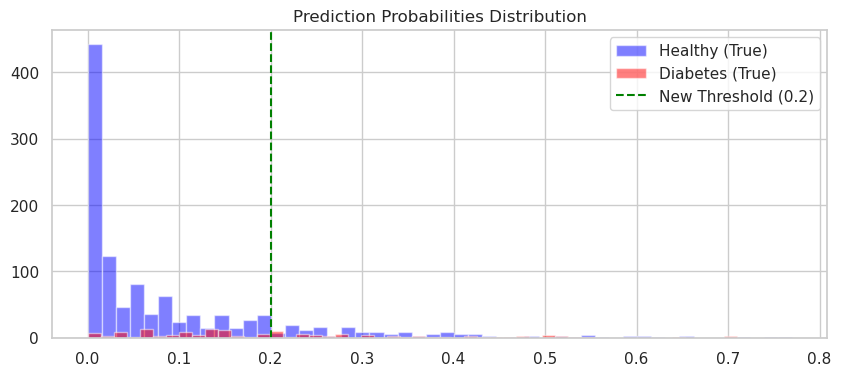

--- 阈值调整为 0.2 后的诊断报告 ---
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1136
           1       0.26      0.41      0.31       144

    accuracy                           0.80      1280
   macro avg       0.59      0.63      0.60      1280
weighted avg       0.84      0.80      0.82      1280

新召回率 (Recall): 0.41


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import recall_score, precision_score

# 1. 获取“概率”而不是直接获取“结果”
# predict_proba 会返回两列：[没病的概率, 有病的概率]
# 我们只取第二列 ([:, 1])，即“患病概率”
y_prob = rf_balanced.predict_proba(X_test)[:, 1]

# 2. 看看模型到底在想什么 (画概率分布图)
plt.figure(figsize=(10, 4))
plt.hist(y_prob[y_test==0], bins=50, alpha=0.5, label='Healthy (True)', color='blue')
plt.hist(y_prob[y_test==1], bins=50, alpha=0.5, label='Diabetes (True)', color='red')
plt.axvline(x=0.2, color='green', linestyle='--', label='New Threshold (0.2)')
plt.title('Prediction Probabilities Distribution')
plt.legend()
plt.show()

# 3. 强行调整阈值
threshold = 0.2  # <--- 我们手动把门槛降到 20%
y_pred_new = (y_prob >= threshold).astype(int)

# 4. 看看新成绩
print(f"--- 阈值调整为 {threshold} 后的诊断报告 ---")
print(classification_report(y_test, y_pred_new))

print(f"新召回率 (Recall): {recall_score(y_test, y_pred_new):.2f}")

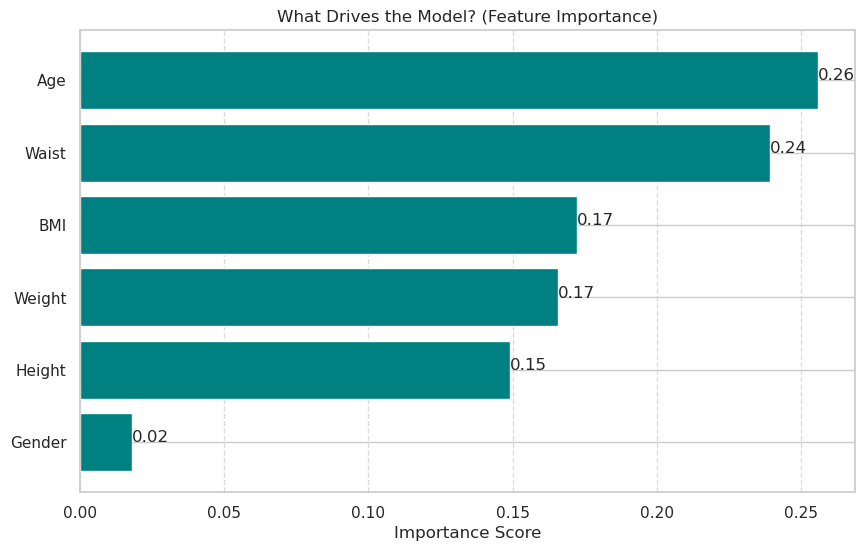

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 从模型中提取“特征重要性”数值
importances = rf_balanced.feature_importances_

# 2. 把它转换成 DataFrame 方便画图
# feature_cols 是我们在前面定义的 ['Age', 'Gender', 'BMI', 'Waist', 'Height', 'Weight']
df_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
})

# 3. 排序 (让最重要的排在最上面)
df_importance = df_importance.sort_values(by='Importance', ascending=True)

# 4. 画个漂亮的横向条形图
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('What Drives the Model? (Feature Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 显示数值
for index, value in enumerate(df_importance['Importance']):
    plt.text(value, index, f'{value:.2f}')

plt.show()